# CNN (Convolutional Neural Networks)

... I am going old school and starting with putting thoughts on paper (perhaps more reasons to use my supernote ;) before getting into code and literature...

![CNN page 1](../_asset/cnn/cnn_1.png)

![CNN Page 2](../_asset/cnn/cnn_2.png)

##### Will undestanding this by building a ConvNet using PyTorch and training it using CIFAR-10 dataset

### CIFAR-10 dataset
[download](https://www.cs.toronto.edu/~kriz/cifar.html)

CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

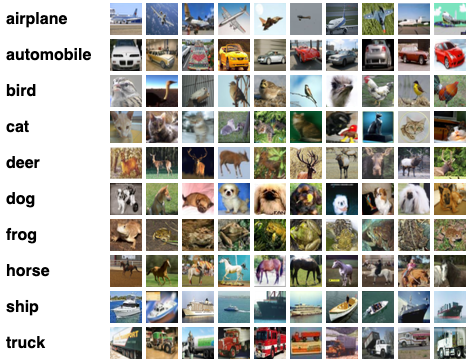

In [1]:
import os
import tarfile
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
import urllib.request

DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
tgz_path = DATA_DIR / "cifar-10-python.tar.gz"
extract_dir = DATA_DIR

if not tgz_path.exists():
    print("Downloading...")
    urllib.request.urlretrieve(url, tgz_path)

print("Extracting...")
with tarfile.open(tgz_path, "r:gz") as tar:
    tar.extractall(path=extract_dir)

cifar_dir = extract_dir / "cifar-10-batches-py"
print("CIFAR dir:", cifar_dir, "exists?", cifar_dir.exists())

Extracting...


/var/folders/hr/kvb_nv256v958_chgsmxrsdm0000gn/T/ipykernel_65363/2772982909.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


CIFAR dir: data/cifar-10-batches-py exists? True


##### CIFAR batches were pickled in python2, so Python3 needs encoding="bytes" or "latin1"

In [4]:
def unpickle(path: Path) -> dict:
    with open(path, "rb") as f:
        return pickle.load(f, encoding="bytes")

sorted([p.name for p in cifar_dir.iterdir()])

['batches.meta',
 'data_batch_1',
 'data_batch_2',
 'data_batch_3',
 'data_batch_4',
 'data_batch_5',
 'readme.html',
 'test_batch']

In [5]:
data_batch_1 = unpickle(cifar_dir / "data_batch_1")
print(data_batch_1.keys())
print("Batch 1 shape: ",data_batch_1[b"data"].shape)
print("First 10 labels: ",[class_names[label] for label in data_batch_1[b"labels"][:10]])

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
Batch 1 shape:  (10000, 3072)
First 10 labels:  ['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat']


##### CIFAR stores R, G and B flat - each 1024 bytes i.e. R = 32x32 = 1024. Combining all 3 channels would be 3072 bytes. Our next task is to convert "flat 3072" bytes into real images (N, 32, 32, 3) where N is the number of samples

In [6]:
def to_image(x_flat: np.ndarray) -> np.ndarray:
    x = x_flat.reshape(-1, 3, 32, 32)          # (N, C, H, W)
    x = np.transpose(x, (0, 2, 3, 1))          # (N, H, W, C)
    return x

x_batch1 = to_image(data_batch_1[b"data"])
y_batch1 = np.array(data_batch_1[b"labels"])

x_batch1.shape, x_batch1.dtype,y_batch1.shape, y_batch1.dtype

((10000, 32, 32, 3), dtype('uint8'), (10000,), dtype('int64'))

##### Visualize one sample image on a 32x32 grid

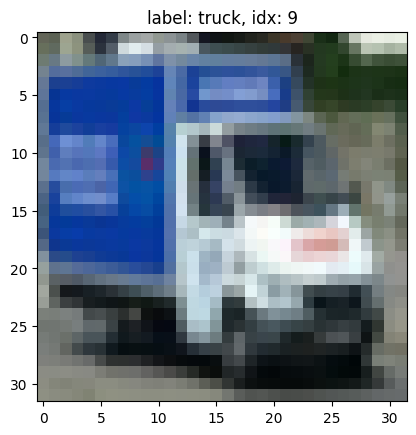

In [7]:
# index = np.random.randint(0, 10000)
sample = 4667
plt.imshow(x_batch1[sample])
plt.title(f"label: {class_names[y_batch1[sample]]}, idx: {y_batch1[sample]}")
# plt.axis('off')
plt.show()

##### Lets load all the 5 training batches and 1 test batch from CIFAR

In [8]:
# Loading testing batch
test_batch = unpickle(cifar_dir / "test_batch")
X_test = to_image(test_batch[b"data"])
y_test = np.array(test_batch[b"labels"])

X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000,))

In [9]:
# Training batch...
xs, ys = [], []
for i in range(1, 6):
    batch = unpickle(cifar_dir / f"data_batch_{i}")
    x = to_image(batch[b"data"])
    y = np.array(batch[b"labels"])
    xs.append(x)
    ys.append(y)

X_train = np.concatenate(xs, axis=0)
y_train = np.concatenate(ys, axis=0)

X_train.shape, y_train.shape

((50000, 32, 32, 3), (50000,))

### ConvNet

The goal to build a simple ConvNet using PyTorch and train it on CIFAR 10 dataset. I wanted to visualize all the layers to look at the activation map. Lets consider below pipeline

> input(32×32×3) → conv/relu → pool → conv/relu → pool → conv/relu → pool → FC

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [74]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2)
        self.relu1 = nn.ReLU(inplace=False)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 20, kernel_size=5, stride=1, padding=2)
        self.relu2 = nn.ReLU(inplace=False)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(20, 20, kernel_size=5, stride=1, padding=2)
        self.relu3 = nn.ReLU(inplace=False)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(20 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.conv1(x)  
        x = self.relu1(x)  
        x = self.pool1(x)  

        x = self.conv2(x)  
        x = self.relu2(x)  
        x = self.pool2(x)  

        x = self.conv3(x)  
        x = self.relu3(x)  
        x = self.pool3(x)  

        x = torch.flatten(x, 1)  
        x = self.fc(x)           
        return x

model = SimpleConvNet().to(device)

print("conv(n) = (input depth, no of kernels, kernel size, stride, padding))\n")
print(model)

conv(n) = (input depth, no of kernels, kernel size, stride, padding))

SimpleConvNet(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=320, out_features=10, bias=True)
)


With input being (3,32,32) - the output shape of each layers
- (16,32,32) conv1/relu
- (16,16,16) pool1
- (20,16,16) conv2/relu
- (20,8,8) pool2
- (20,8,8) conv3/relu
- (20,4,4) pool3
- (320,) FC (feature vector)
- (10,) logits
- (10,) softmax probability distribution

##### Model Parameters (weights and bias)

In [85]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"==> Total Trainable Params: {total_params:,}\n")

print("--- Parameters per layer ---")
for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        print(f"[{name}]", "-" * 70)
        
        # 1. Print Hyperparameters
        if isinstance(module, nn.Conv2d):
            print(f"  Config:  Kernel {module.kernel_size}   |   Stride {module.stride}   |   Padding {module.padding}")
        elif isinstance(module, nn.Linear):
            print(f"  Config:  In {module.in_features} -> Out {module.out_features}")

        for p_name, p_tensor in module.named_parameters(recurse=False):
            print(f"  Param:   {p_name:<10}   |   Shape: {str(p_tensor.shape):<20}   |   Count: {p_tensor.numel()}")

==> Total Trainable Params: 22,466

--- Parameters per layer ---
[conv1] ----------------------------------------------------------------------
  Config:  Kernel (5, 5)   |   Stride (1, 1)   |   Padding (2, 2)
  Param:   weight       |   Shape: torch.Size([16, 3, 5, 5])   |   Count: 1200
  Param:   bias         |   Shape: torch.Size([16])       |   Count: 16
[conv2] ----------------------------------------------------------------------
  Config:  Kernel (5, 5)   |   Stride (1, 1)   |   Padding (2, 2)
  Param:   weight       |   Shape: torch.Size([20, 16, 5, 5])   |   Count: 8000
  Param:   bias         |   Shape: torch.Size([20])       |   Count: 20
[conv3] ----------------------------------------------------------------------
  Config:  Kernel (5, 5)   |   Stride (1, 1)   |   Padding (2, 2)
  Param:   weight       |   Shape: torch.Size([20, 20, 5, 5])   |   Count: 10000
  Param:   bias         |   Shape: torch.Size([20])       |   Count: 20
[fc] ---------------------------------------

##### Prepare test and training data

Our current Input shape is `X.shape == (num_images, height, width, channels)` e.g. `(N, 32, 32, 3)` but PyTorch ConvNets expects a different shape i.e. `(N, channels, height, width)` e.g `(N, 3, 32, 32)`

premute(0,3,1,2) would reorders `(N, H, W, C)`   →   `(N, C, H, W)` 
>(note `/ 255.0` normalizes pixel values)

In [12]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

batch_size = 128

Xtr = torch.from_numpy(X_train).permute(0,3,1,2).float() / 255.0
ytr = torch.from_numpy(y_train).long()
Xte = torch.from_numpy(X_test).permute(0,3,1,2).float() / 255.0
yte = torch.from_numpy(y_test).long()

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=batch_size, shuffle=False)

print("Batch size:", batch_size)
print("Train batches:", len(train_loader), "Test batches:", len(test_loader))

Batch size: 128
Train batches: 391 Test batches: 79


##### Train and Evaluate

Each epoch would still go over entire dataset (50K CIFAR samples) - so with batch_size 128, we will have 390 batches. The train_loader would scoop in 128 in each iteration...

In [ ]:
current_epoch = 0
total_epochs = 15

import time

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

loss_fn = nn.CrossEntropyLoss()

def calculate_loss_accuracy(running_loss, correct, total):
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    # one mini batch at a time...
    for batch_idx, (x, y) in enumerate(train_loader):

        # move to device
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()  # reset gradients

        logits = model(x) # forward pass
        loss = loss_fn(logits, y) # compute loss

        loss.backward() # backpropagation
        optimizer.step() # update parameters, we are using Stochastic Gradient Descent -> weight = weight - lr * grad (plus momentum/weight_decay)

        running_loss += loss.item() * x.size(0)
        total += x.size(0)

        correct += (logits.argmax(dim=1) == y).sum().item()

    epoch_loss, epoch_acc = calculate_loss_accuracy(running_loss, correct, total)
    elapsed = time.time() - start_time
    return epoch_loss, epoch_acc, elapsed

def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            running_loss += loss.item() * x.size(0)
            total += x.size(0)

            correct += (logits.argmax(dim=1) == y).sum().item()

    test_loss, test_accuracy = calculate_loss_accuracy(running_loss, correct, total)
    return test_loss, test_accuracy

def run_one_epoch():
    global current_epoch
    current_epoch = current_epoch + 1
    
    epoch_loss, epoch_acc, elapsed = train(current_epoch)
    test_loss, test_acc = evaluate(test_loader)

    print(f"Train Epoch {current_epoch}/{total_epochs} - Time: {elapsed:.2f}s \n==>"
        f"Training Loss: {epoch_loss:.4f} - "
        f"Training Accuracy: {epoch_acc*100:.2f}% - "
        f"Test Loss: {test_loss:.4f} - "
        f"Test Accuracy: {test_acc*100:.2f}%")

#### Single Epoch Run

In [14]:
run_one_epoch()

Train Epoch 1/15 - Time: 20.27s 
==>Training Loss: 2.0125 - Training Accuracy: 25.67% - Test Loss: 1.7398 - Test Accuracy: 36.02%


#### Lets do some inference - the model will perform bogus... I promise

some visualization functions to show activations of output labels with progress bar...

In [15]:
import matplotlib.pyplot as plt

def denorm_cifar(img_chw):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return img_chw * std + mean

# we normalized during dataset creation, we need to de-normalize for display
def denorm_if_needed(img_chw):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return (img_chw * std + mean).clamp(0, 1)

def show_predictions(
    x_batch, y_true, probs,
    n=12, cols=2, topk=5,
    font=16, fig_scale=1.0
):
    x_cpu = x_batch.detach().cpu()
    y_cpu = y_true.detach().cpu()
    p_cpu = probs.detach().cpu()

    pred = p_cpu.argmax(dim=1)
    rows = (n + cols - 1) // cols
    total_cols = cols * 2

    fig = plt.figure(figsize=(total_cols * 5.5 * fig_scale, rows * 4.2 * fig_scale))
    gs = fig.add_gridspec(rows, total_cols, width_ratios=[1.25, 1.0] * cols, wspace=0.25, hspace=0.5)

    for i in range(n):
        r = i // cols
        c = i % cols

        ax_img = fig.add_subplot(gs[r, c*2])
        ax_bar = fig.add_subplot(gs[r, c*2 + 1])

        # ----- image -----
        img_t = x_cpu[i]
        # If values look normalized (roughly centered around 0), de-normalize; else show as-is.
        if img_t.min() < 0 or img_t.max() > 1:
            img_t = denorm_cifar(img_t)   # only if you actually normalized earlier

        img = img_t.clamp(0, 1).permute(1,2,0).numpy()

        ax_img.imshow(img)
        ax_img.axis("off")

        gt_idx = int(y_cpu[i])
        pr_idx = int(pred[i])
        ok = (gt_idx == pr_idx)

        gt = class_names[gt_idx]
        pr = class_names[pr_idx]

        ax_img.set_title(
            f"ground truth: {gt}  |  pred: {pr}",
            fontsize=font, pad=10
        )

        # ----- top-k bars -----
        vals, idxs = torch.topk(p_cpu[i], k=topk)

        # reverse so the biggest ends up at the TOP after invert_yaxis()
        vals = vals.numpy()[::-1]
        idxs = idxs.numpy()[::-1]
        labels = [class_names[j] for j in idxs]

        # Colors: if correct => GT bar green (if present), others red. if incorrect => all red.
        colors = []
        for cls_idx in idxs:
            if ok and int(cls_idx) == gt_idx:
                colors.append("green")
            else:
                colors.append("red")

        y_pos = np.arange(topk)
        bars = ax_bar.barh(y_pos, vals, color=colors)

        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(labels, fontsize=font-2)
        ax_bar.set_xlim(0, 1.0)
        ax_bar.tick_params(axis="x", labelsize=font-2)
        ax_bar.set_xlabel("prob", fontsize=font-2)

        # values at end of bars
        for b, v in zip(bars, vals):
            ax_bar.text(
                min(v + 0.02, 0.98),
                b.get_y() + b.get_height()/2,
                f"{v:.2f}",
                va="center",
                fontsize=font-2
            )

        ax_bar.invert_yaxis()

    plt.tight_layout()
    plt.show()

cherry pick 200 samples from test data and calcualte accuracy... The seed will ensure same sample for each epoch so that we can see it building up to confidence...

In [20]:
import torch
import numpy as np

def test_random_200():
    np.random.seed(24)
    idx200 = np.random.choice(len(Xte), size=200, replace=False)

    x200 = Xte[idx200].to(device)   # (200,3,32,32)
    y200 = yte[idx200].to(device)   # (200,)

    # set model to eval mode and get predictions
    model.eval()
    with torch.no_grad():
        logits200 = model(x200)
        probs200 = torch.softmax(logits200, dim=1)

    # calculate accuracy on these 200
    acc200 = (probs200.argmax(dim=1) == y200).float().mean().item()
    print("\n==> Test accuracy on random 200 from test set:", round(acc200, 4))

    show_predictions(
        x200, y200, probs200,
        n=20, cols=2, topk=5,
        font=14, fig_scale=1.0
    )


##### test after 1 epoch


==> Test accuracy on random 200 from test set: 0.345


/var/folders/hr/kvb_nv256v958_chgsmxrsdm0000gn/T/ipykernel_65363/912593212.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


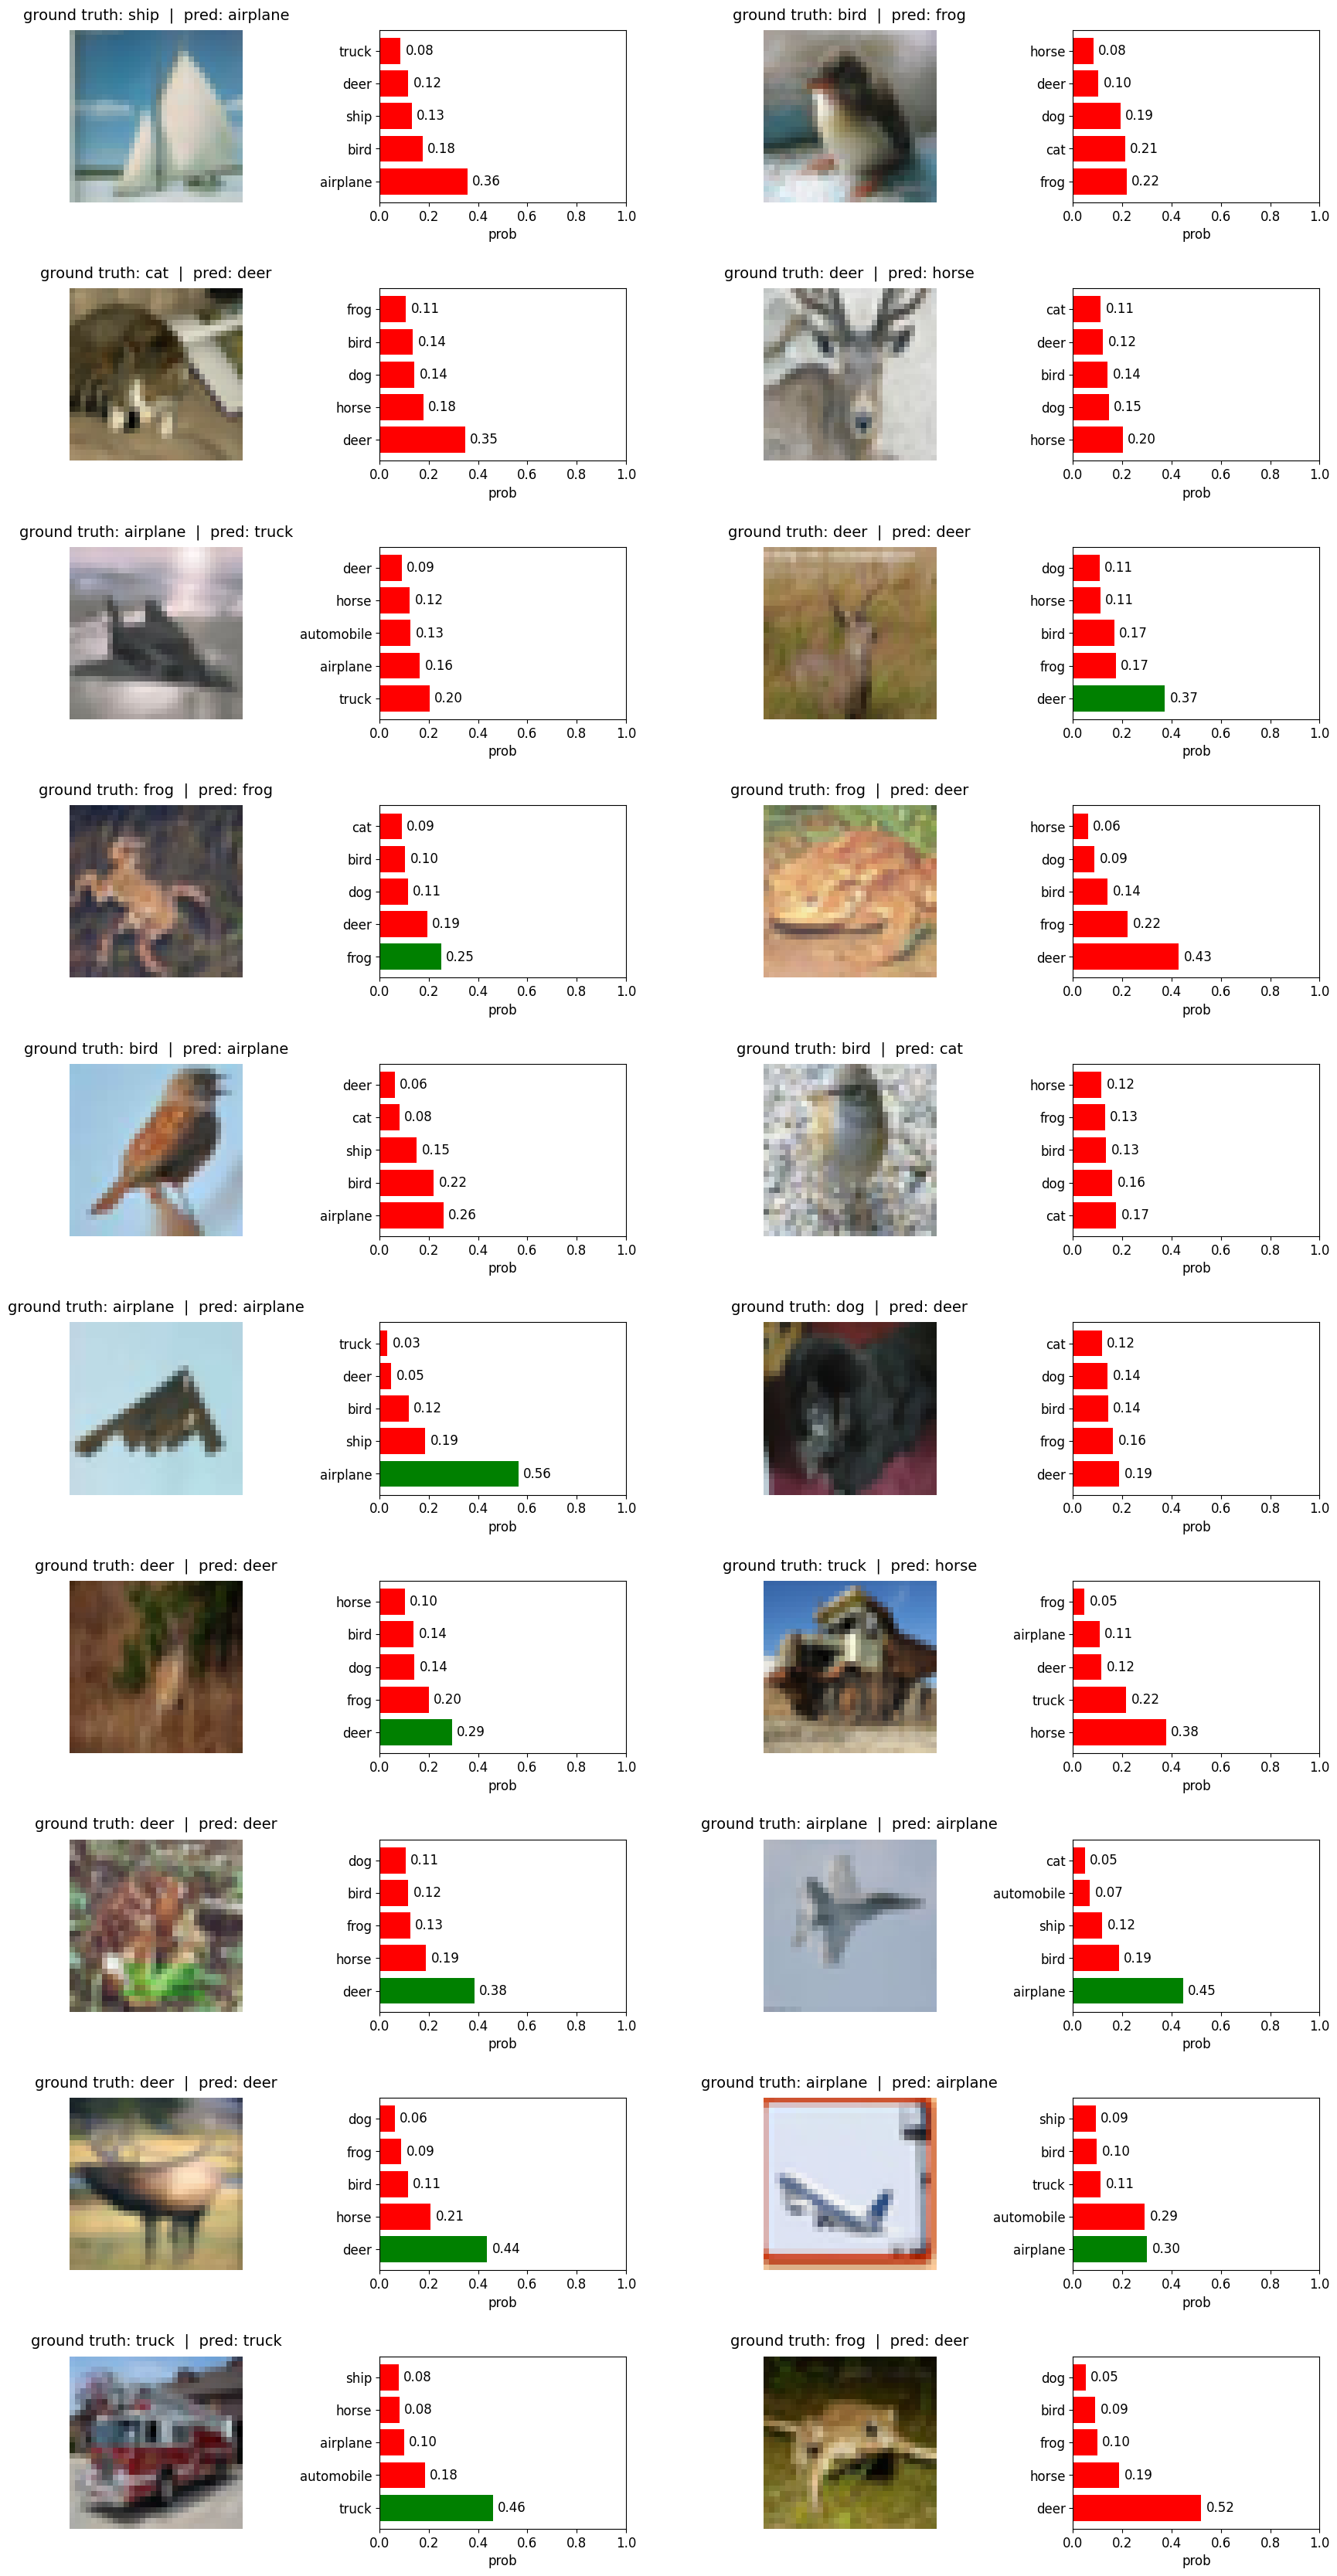

In [21]:
test_random_200()

#### Running it for remainder of epoch (total 15) and perform the test again on the same sample...

Train Epoch 2/15 - Time: 17.07s 
==>Training Loss: 1.5760 - Training Accuracy: 43.49% - Test Loss: 1.5136 - Test Accuracy: 46.31%
Train Epoch 3/15 - Time: 16.79s 
==>Training Loss: 1.4043 - Training Accuracy: 49.82% - Test Loss: 1.3750 - Test Accuracy: 50.47%
Train Epoch 4/15 - Time: 16.66s 
==>Training Loss: 1.2846 - Training Accuracy: 54.38% - Test Loss: 1.2802 - Test Accuracy: 55.78%
Train Epoch 5/15 - Time: 16.41s 
==>Training Loss: 1.1896 - Training Accuracy: 58.25% - Test Loss: 1.1818 - Test Accuracy: 58.91%
Train Epoch 6/15 - Time: 16.45s 
==>Training Loss: 1.1210 - Training Accuracy: 60.96% - Test Loss: 1.1142 - Test Accuracy: 61.12%
Train Epoch 7/15 - Time: 16.74s 
==>Training Loss: 1.0610 - Training Accuracy: 63.04% - Test Loss: 1.1105 - Test Accuracy: 60.73%
Train Epoch 8/15 - Time: 17.31s 
==>Training Loss: 1.0010 - Training Accuracy: 65.05% - Test Loss: 1.0576 - Test Accuracy: 63.30%
Train Epoch 9/15 - Time: 17.17s 
==>Training Loss: 0.9803 - Training Accuracy: 65.75% - Te

/var/folders/hr/kvb_nv256v958_chgsmxrsdm0000gn/T/ipykernel_65363/912593212.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


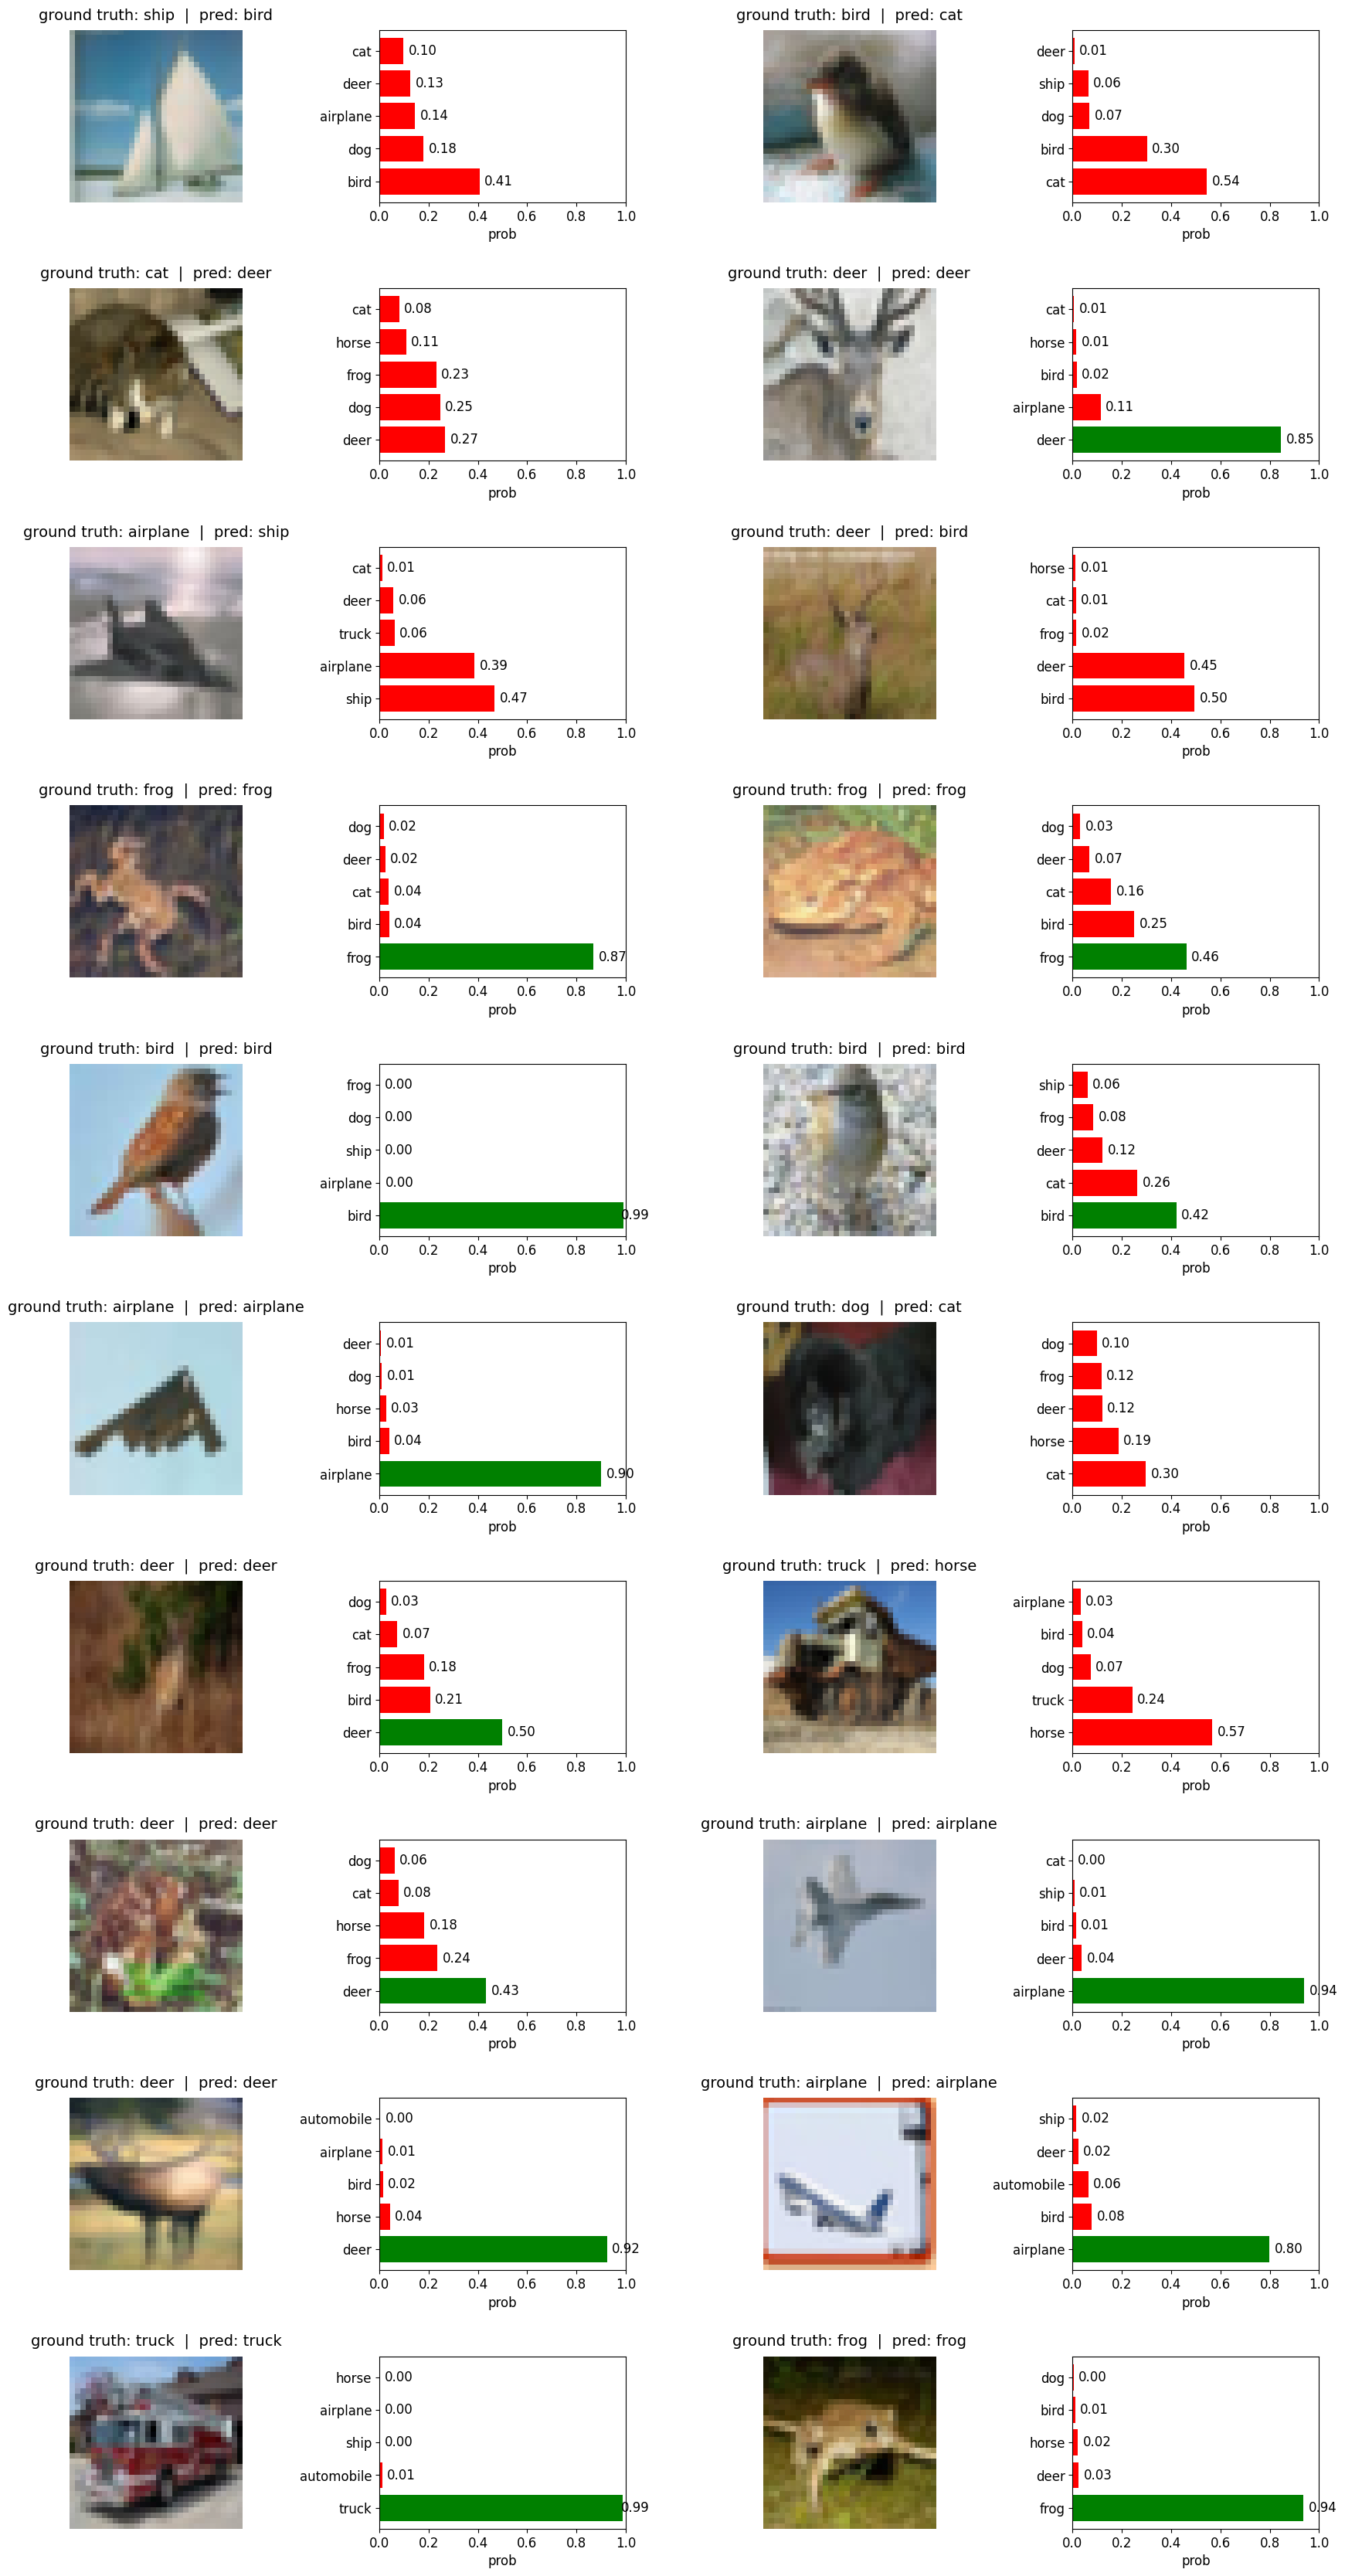

In [22]:
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
run_one_epoch()
# run the test again...
test_random_200()

### Visualize Conv Layers

we will create a simple hook to save the activations output. This will be registered as forward hooks with each layer. Since `activations` is a simple object, it will be overwritten for each input tensor during training

In [23]:
activations = {}

def save_activation(name):
    def hook(module, inp, out):
        # out is (B,C,H,W); store only first sample -> (C,H,W)
        activations[name] = {"act": out[0].detach().cpu()}
    return hook

we will name the layers to store the activations outputs... we will use this later for visualizations

In [24]:
META = "__meta__"
CONV1 = "conv1 (32x32x16)"
RELU1 = "relu1 (32x32x16)"
POOL1 = "pool1 (16x16x16)"
CONV2 = "conv2 (16x16x20)"
RELU2 = "relu2 (16x16x20)"
POOL2 = "pool2 (8x8x20)"
CONV3 = "conv3 (8x8x20)"
RELU3 = "relu3 (8x8x20)"
POOL3 = "pool3 (4x4x20)"

##### Capture activations with forward hooks
we will use this for visualizations

In [25]:
hooks = []
hooks.append(model.conv1.register_forward_hook(save_activation(CONV1)))
hooks.append(model.relu1.register_forward_hook(save_activation(RELU1)))
hooks.append(model.pool1.register_forward_hook(save_activation(POOL1)))
hooks.append(model.conv2.register_forward_hook(save_activation(CONV2)))
hooks.append(model.relu2.register_forward_hook(save_activation(RELU2)))
hooks.append(model.pool2.register_forward_hook(save_activation(POOL2)))
hooks.append(model.conv3.register_forward_hook(save_activation(CONV3)))
hooks.append(model.relu3.register_forward_hook(save_activation(RELU3)))
hooks.append(model.pool3.register_forward_hook(save_activation(POOL3)))

... single forward pass so that we capture the activation maps

In [28]:
sample = 4667
activations.clear()

# Build a (1,3,32,32) tensor
x1 = torch.from_numpy(x_batch1[sample]).float() / 255.0          # (32,32,3)
x1 = x1.permute(2,0,1).unsqueeze(0).to(device)                   # (1,3,32,32)

# Store meta (optional but nice)
activations[META] = {
    "sample": sample,
    "y": int(y_batch1[sample]),
    "x": x1[0].detach().cpu(),   # (3,32,32)
}

model.eval()
with torch.no_grad():
    logits = model(x1)   # hooks would fire here...
    prob = torch.softmax(logits, dim=1)

tensor([[-0.6300,  7.2815, -2.9838, -2.7433, -4.4819, -3.8679, -3.6393, -5.6147,
          2.9944, 11.9750]])

In [35]:
import matplotlib.pyplot as plt

def show_activation_maps(activation_maps, title, max_channels=16, cols=8):
    t = activation_maps.detach().cpu()
    C, H, W = t.shape
    n = min(C, max_channels)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols*1.6, rows*1.6))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(t[i].numpy())
        ax.axis("off")
    plt.suptitle(f"{title} (showing {n}/{C} channels)")
    plt.tight_layout()
    plt.show()


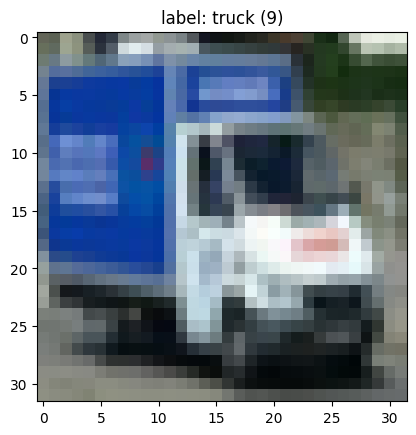

--- Predictions for Sample 4667 ---
airplane  :   0.00%
automobile:   0.91%
bird      :   0.00%
cat       :   0.00%
deer      :   0.00%
dog       :   0.00%
frog      :   0.00%
horse     :   0.00%
ship      :   0.01%
truck     :  99.08%


In [43]:
img = activations[META]["x"].permute(1,2,0).numpy()
plt.imshow(img)
plt.title(f"label: {class_names[activations[META]['y']]} ({activations[META]['y']})")
plt.show()
probs = prob[0].cpu().numpy()

print(f"--- Predictions for Sample {activations[META]['sample']} ---")
for i, p in enumerate(probs):
    name = class_names[i]
    percentage = p * 100
    print(f"{name:10}: {percentage:>6.2f}%")


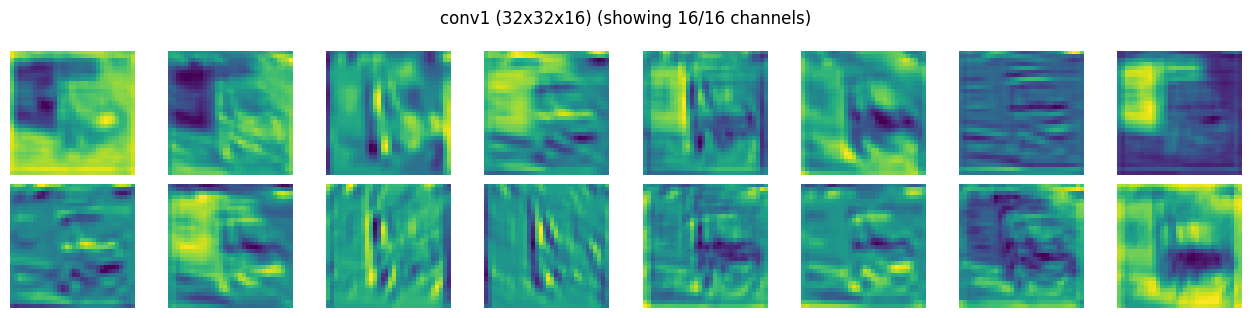

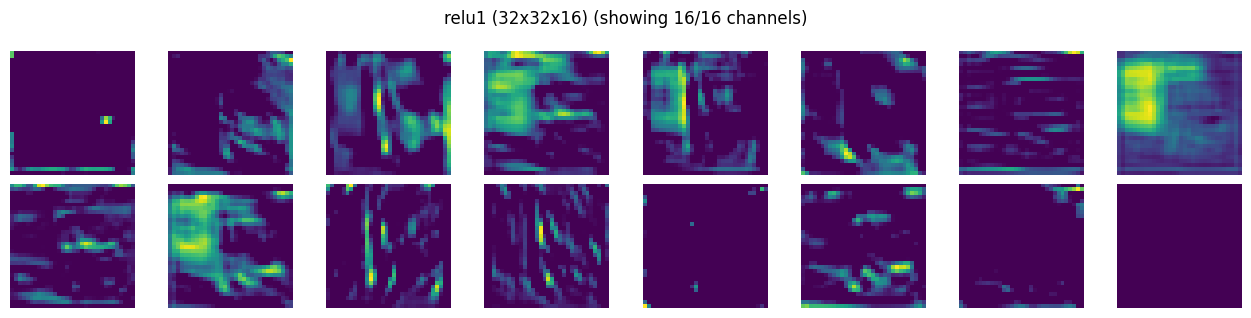

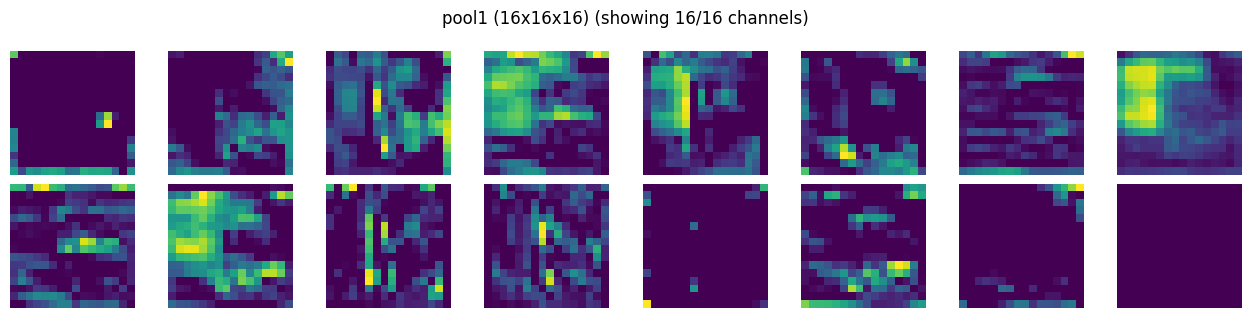

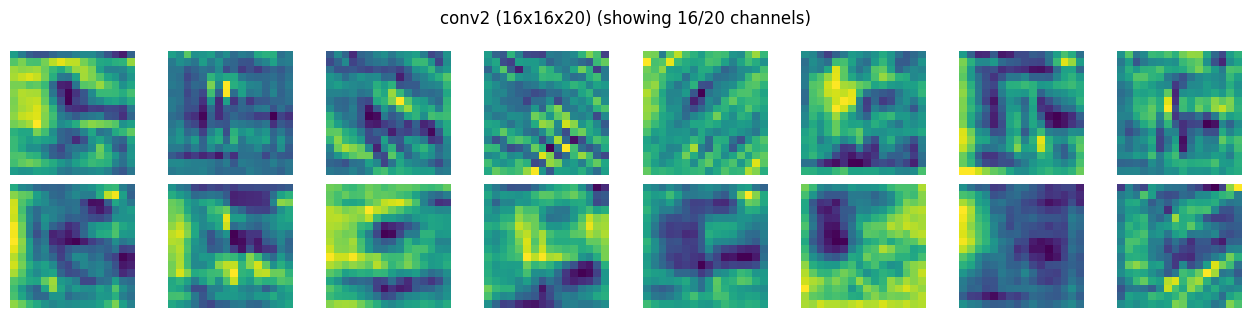

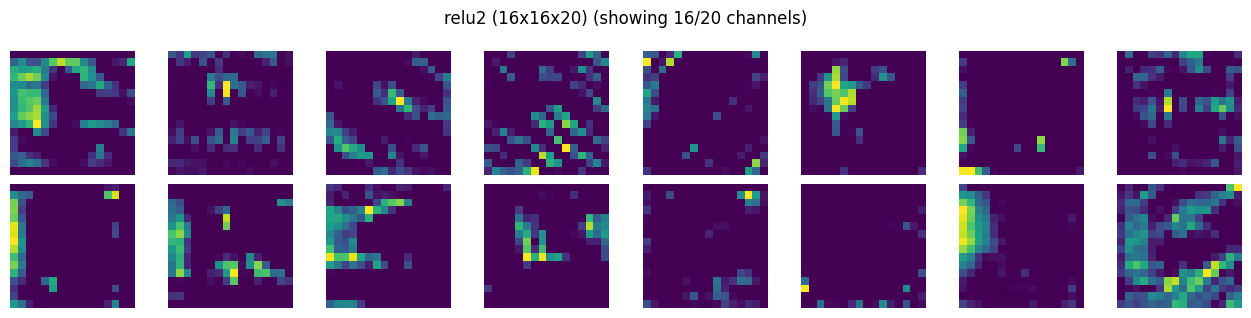

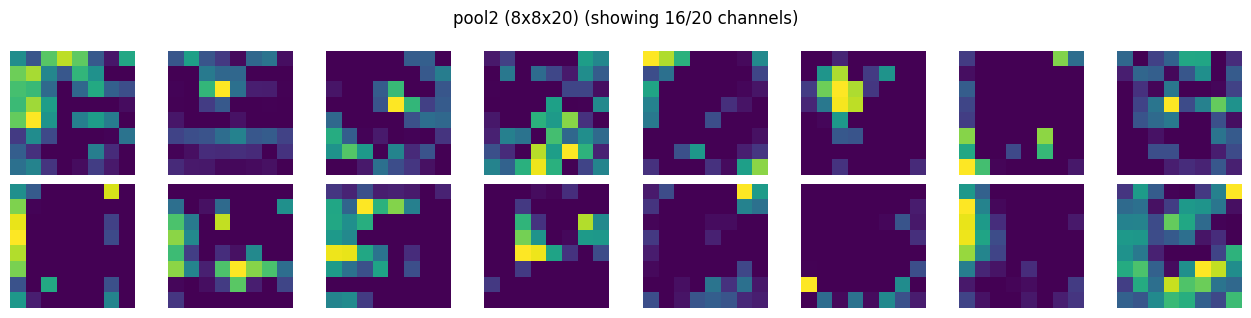

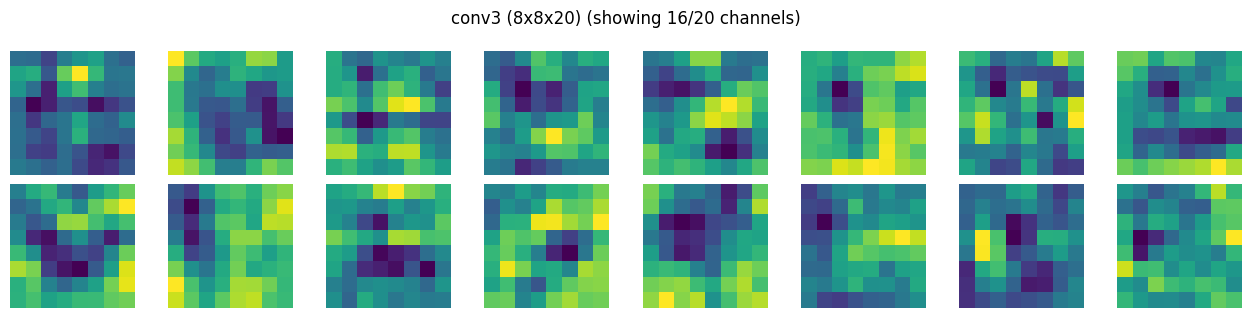

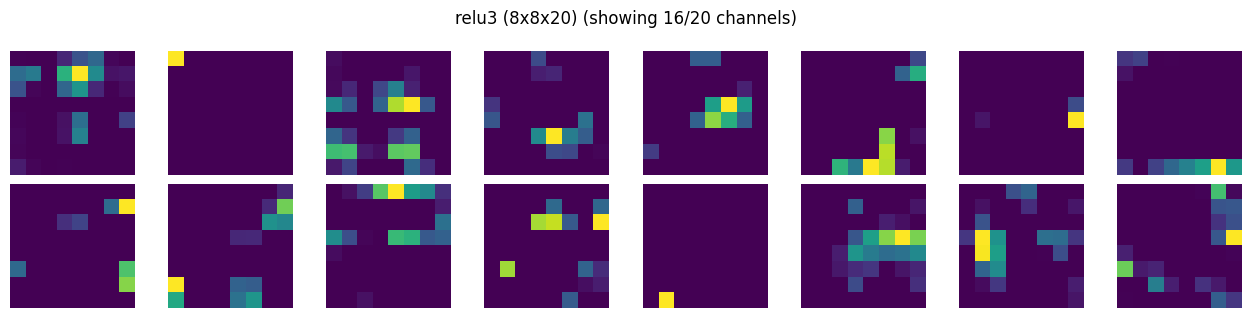

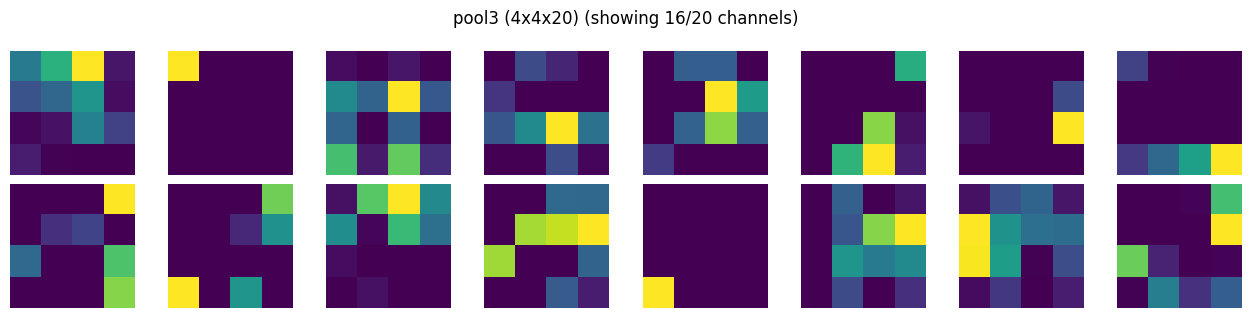

In [36]:
# show feature maps per layer
show_activation_maps(activations[CONV1]["act"], CONV1)
show_activation_maps(activations[RELU1]["act"], RELU1)
show_activation_maps(activations[POOL1]["act"], POOL1)

show_activation_maps(activations[CONV2]["act"], CONV2)
show_activation_maps(activations[RELU2]["act"], RELU2)
show_activation_maps(activations[POOL2]["act"], POOL2)

show_activation_maps(activations[CONV3]["act"], CONV3)
show_activation_maps(activations[RELU3]["act"], RELU3)
show_activation_maps(activations[POOL3]["act"], POOL3)


#### Just for science
this is how the kernal or filter looks like post training for CONV1

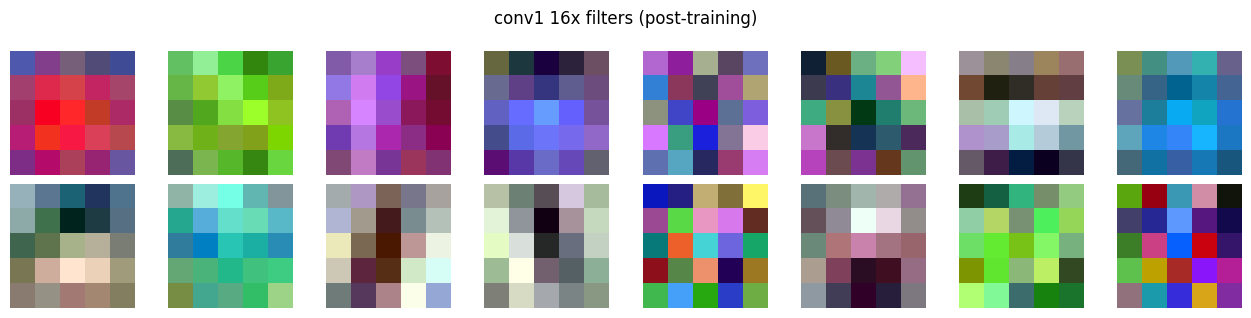

In [37]:
def show_conv_filters(weight: torch.Tensor, max_filters=16, cols=8, title=""):
    W = weight.detach().cpu()
    out_ch, in_ch, kH, kW = W.shape
    n = min(out_ch, max_filters)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 1.6, rows * 1.6))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        w = W[i]

        if in_ch == 3:
            img = w.permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            ax.imshow(img)
        else:
            ax.imshow(w[0].numpy())
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_conv_filters(model.conv1.weight, title="conv1 16x filters (post-training)")